# Exploratory Data Analysis
**phoebe** — predicting secondary school performance using data mining

Dataset: [UCI Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance) — Math (`student-mat.csv`) and Portuguese (`student-por.csv`).

In [2]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data import load_math, load_portuguese
from src.models import (
    apply_dummies,
    encode_features,
    evaluate_classifier,
    evaluate_model,
    fit_elastic_net,
    fit_lasso,
    fit_logistic,
    fit_random_forest,
    fit_ridge,
    prepare_features,
)

sns.set_theme(style="whitegrid")

## 0. Load data

In [3]:
mat = load_math()
por = load_portuguese()

print("Math:      ", mat.shape)
print("Portuguese:", por.shape)

Math:       (395, 33)
Portuguese: (649, 33)


## 1. Data Overview

### Basics

In [4]:
mat.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
mat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
por.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


### Missing Values 

In [7]:
for name, df in [("Math", mat), ("Portuguese", por)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name}: no missing values")
    else:
        print(f"{name}: {missing.sum()} missing values\n{missing}\n")

Math: no missing values
Portuguese: no missing values


### Grade distributions

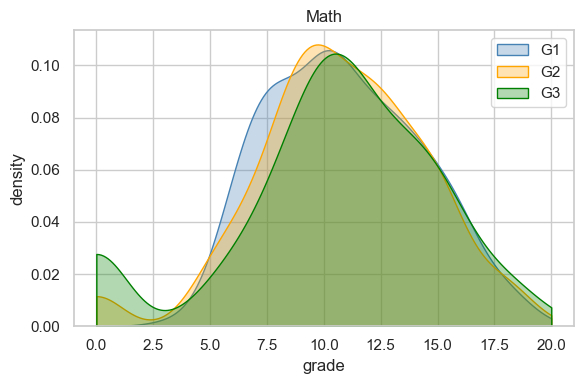

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

for grade, color in zip(["G1", "G2", "G3"], ["steelblue", "orange", "green"]):
    sns.kdeplot(
        mat[grade], ax=ax, fill=True, alpha=0.3, color=color, clip=(0, 20), label=grade
    )
ax.set(title="Math", xlabel="grade", ylabel="density")
ax.legend()

fig.tight_layout()

### Grade distributions

All students recording G3 = 0 are excluded from grade-related analysis. This group comprises two types of withdrawal: 13 mid-year dropouts (G2 = 0 and G3 = 0) and 25 end-of-year withdrawals (G2 > 0, G3 = 0). Both produce artificial trajectories — an end-of-year withdrawal with starting grade G1 = 12 would yield G3 − G1 = −12, distorting the trajectory distribution. All grade-related analysis from this point uses `mat_filtered` (n = 357). Demographic and structural plots above use the full sample (n = 395).


In [9]:
# Filter out all students with G3=0 — includes both mid-year dropouts (G2=0)
# and end-of-year withdrawals (G2>0). Both produce artificial trajectories.
mat_filtered = mat[mat["G3"] != 0].copy()
mat_filtered = mat_filtered.drop(columns=["residual"], errors="ignore")

por_filtered = por[por["G3"] != 0].copy()
por_filtered = por_filtered.drop(columns=["residual"], errors="ignore")

print(f"Math:       {len(mat)} → {len(mat_filtered)} students after filtering")
print(f"Portuguese: {len(por)} → {len(por_filtered)} students after filtering")

Math:       395 → 357 students after filtering
Portuguese: 649 → 634 students after filtering


### KDE of trajectory distributions: Math vs Portuguese, recentered at mean

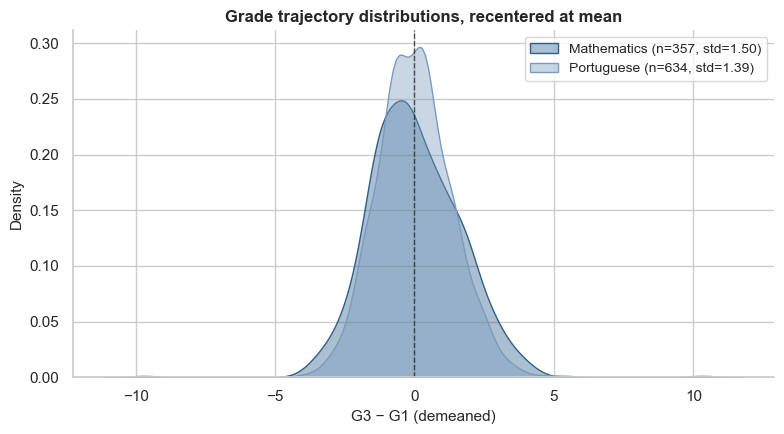

In [10]:
mat_filtered["trajectory"] = mat_filtered["G3"] - mat_filtered["G1"]
por_filtered["trajectory"] = por_filtered["G3"] - por_filtered["G1"]

mat_centered = mat_filtered["trajectory"] - mat_filtered["trajectory"].mean()
por_centered = por_filtered["trajectory"] - por_filtered["trajectory"].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.kdeplot(
    mat_centered,
    ax=ax,
    fill=True,
    alpha=0.4,
    color="#2c5f8a",
    bw_adjust=1.25,
    label=f"Mathematics (n={len(mat_filtered)}, std={mat_filtered['trajectory'].std():.2f})",
)
sns.kdeplot(
    por_centered,
    ax=ax,
    fill=True,
    alpha=0.4,
    color="#7a9bbf",
    bw_adjust=1.25,
    label=f"Portuguese (n={len(por_filtered)}, std={por_filtered['trajectory'].std():.2f})",
)

ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("G3 − G1 (demeaned)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title(
    "Grade trajectory distributions, recentered at mean", fontsize=12, fontweight="bold"
)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(Path(".") / "figures" / "trajectory_kde.png", dpi=150, bbox_inches="tight")
plt.show()

# Drop trajectory to avoid leaking G3 into feature matrices downstream
mat_filtered = mat_filtered.drop(columns=["trajectory"])
por_filtered = por_filtered.drop(columns=["trajectory"])

### Full correlation heatmap

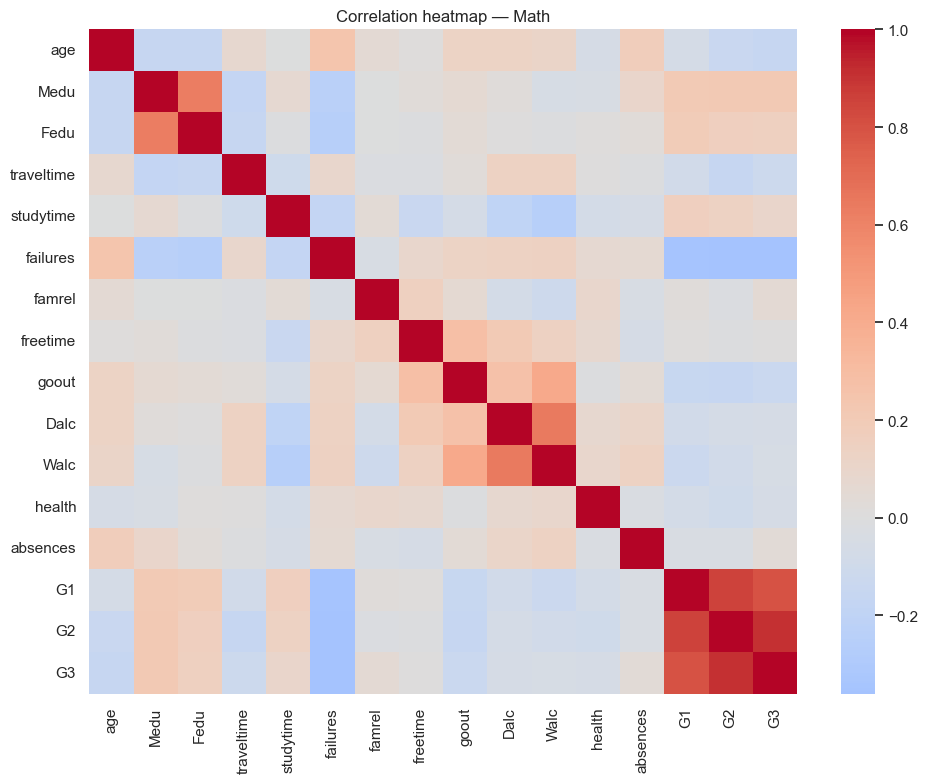

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

numeric = mat.select_dtypes("number")
sns.heatmap(numeric.corr(), ax=ax, cmap="coolwarm", center=0)
ax.set_title("Correlation heatmap — Math")

fig.tight_layout()

Period grades are the strongest predictors of the final grade.

### Categorical feature distribution

/var/folders/cb/stfffc_90v13jltypr67_r0r0000gn/T/ipykernel_91827/2726923577.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


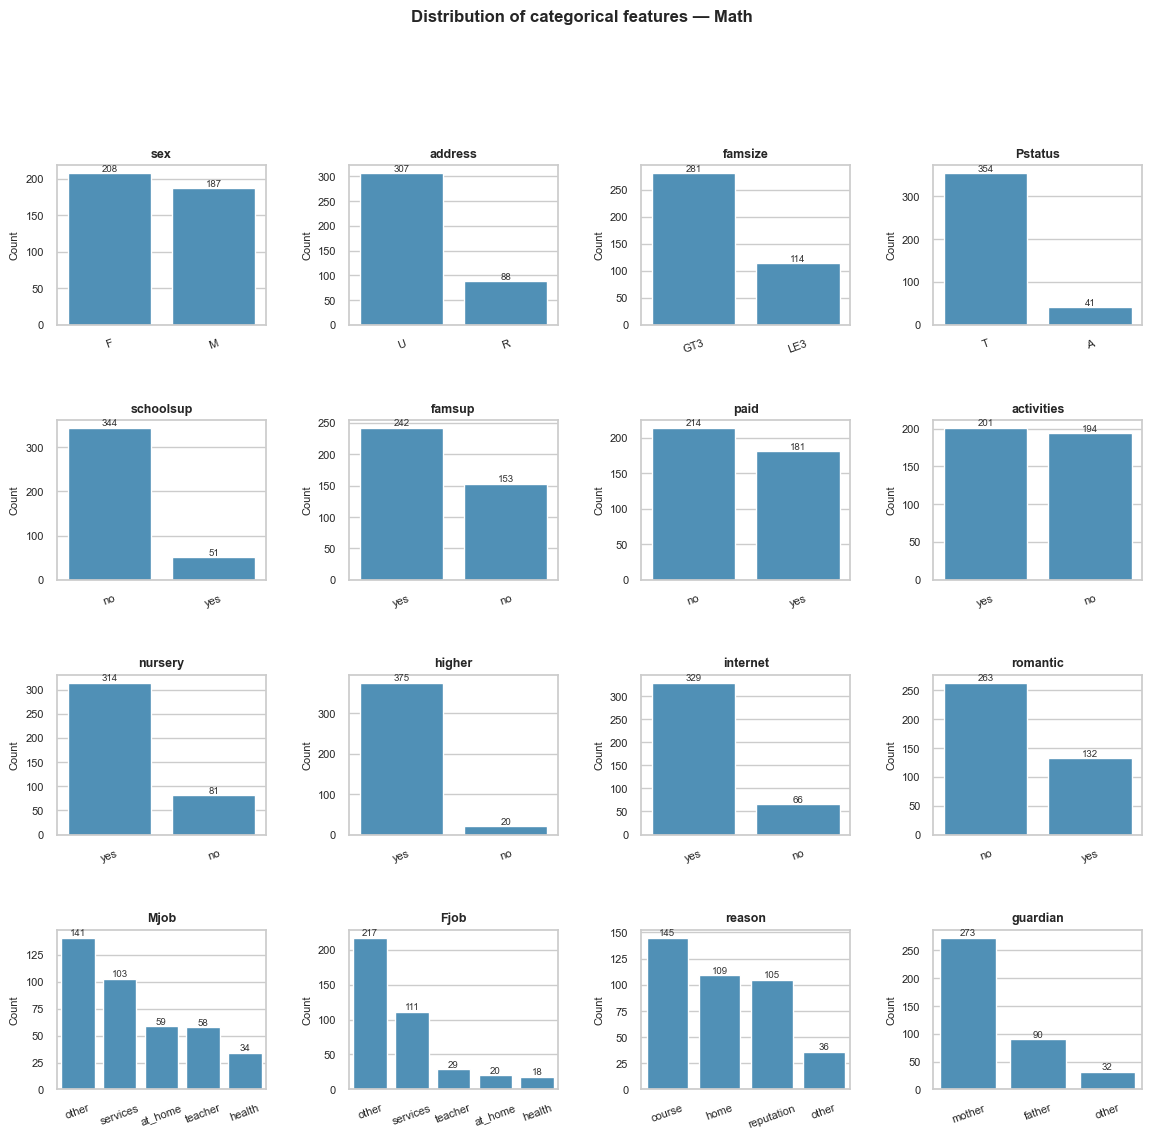

Saved to figures/categorical_distributions.png


In [12]:
# Categorical overview: count plots

cat_cols = [
    # Binary yes/no
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic",
    # Multi-category
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
]

fig, axes = plt.subplots(
    4, 4, figsize=(14, 12), gridspec_kw={"hspace": 0.6, "wspace": 0.4}
)

for ax, col in zip(axes.flat, cat_cols):
    order = mat[col].value_counts().index  # sort by frequency
    sns.countplot(data=mat, x=col, order=order, ax=ax, color="#4393c3", saturation=0.8)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(axis="x", labelsize=8, rotation=20)
    ax.tick_params(axis="y", labelsize=8)
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=7,
            color="#333333",
        )

fig.suptitle(
    "Distribution of categorical features — Math",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
fig_path = Path(".") / "figures" / "categorical_distributions.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {fig_path}")

## 2. Exploratory Data Analysis

### Link between education of the father and mother

/var/folders/cb/stfffc_90v13jltypr67_r0r0000gn/T/ipykernel_91827/3025119142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


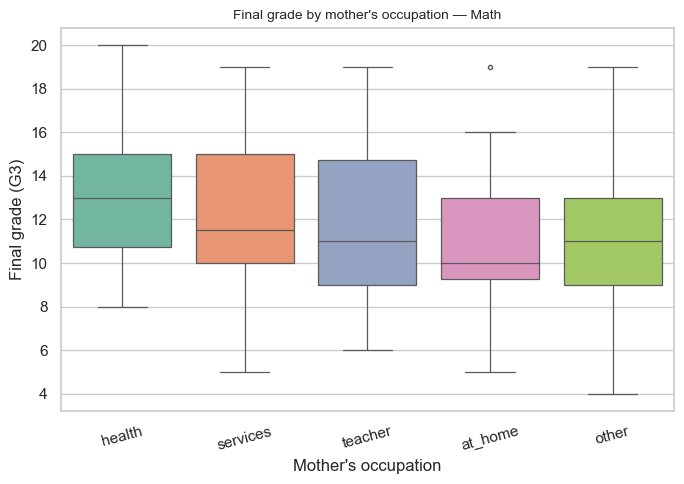

In [13]:
# Order by median G3 descending; push 'other' to the end
job_order_raw = (
    mat_filtered.groupby("Mjob")["G3"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

job_order = [j for j in job_order_raw if j != "other"] + ["other"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=mat_filtered,
    x="Mjob",
    y="G3",
    order=job_order,
    palette="Set2",
    ax=ax,
    linewidth=0.9,
    fliersize=3,
)
ax.set_title("Final grade by mother's occupation — Math", fontsize=10)
ax.set_xlabel("Mother's occupation")
ax.set_ylabel("Final grade (G3)")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()

/var/folders/cb/stfffc_90v13jltypr67_r0r0000gn/T/ipykernel_91827/287513654.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


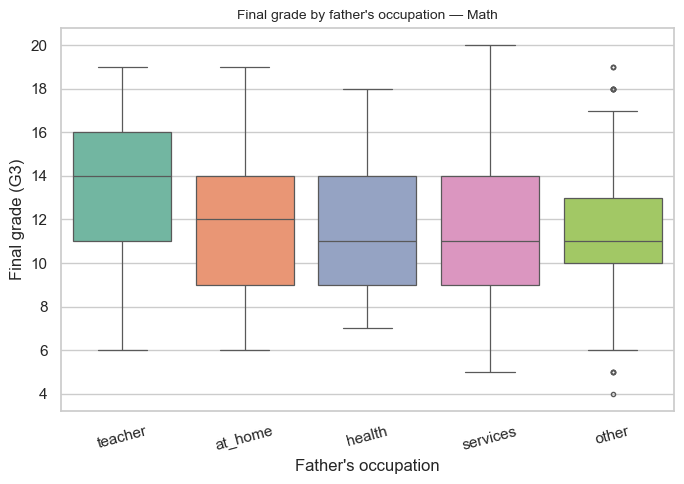

In [14]:
# Order by median G3 descending; push 'other' to the end
fjob_order_raw = (
    mat_filtered.groupby("Fjob")["G3"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fjob_order = [j for j in fjob_order_raw if j != "other"] + ["other"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=mat_filtered,
    x="Fjob",
    y="G3",
    order=fjob_order,
    palette="Set2",
    ax=ax,
    linewidth=0.9,
    fliersize=3,
)
ax.set_title("Final grade by father's occupation — Math", fontsize=10)
ax.set_xlabel("Father's occupation")
ax.set_ylabel("Final grade (G3)")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()

### Absences vs final grade

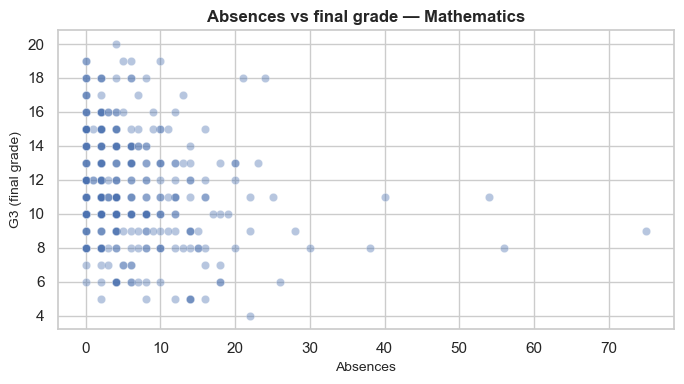

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(data=mat_filtered, x="absences", y="G3", alpha=0.4, ax=ax)
ax.set_title("Absences vs final grade — Mathematics", fontweight="bold")
ax.set_xlabel("Absences", fontsize=10)
ax.set_ylabel("G3 (final grade)", fontsize=10)

plt.tight_layout()

### Spaghetti Plots

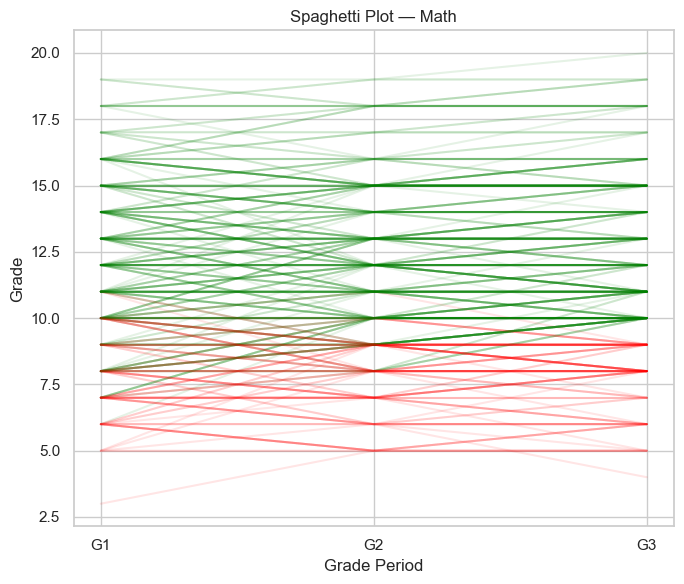

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in mat_filtered.iterrows():
    color = "green" if row["G3"] >= 10 else "red"
    ax.plot([1, 2, 3], [row["G1"], row["G2"], row["G3"]], alpha=0.1, color=color)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["G1", "G2", "G3"])
ax.set_xlabel("Grade Period")
ax.set_ylabel("Grade")
ax.set_title("Spaghetti Plot — Math")

plt.tight_layout()
plt.show()

### Grade Persistence

/var/folders/cb/stfffc_90v13jltypr67_r0r0000gn/T/ipykernel_91827/2818410012.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


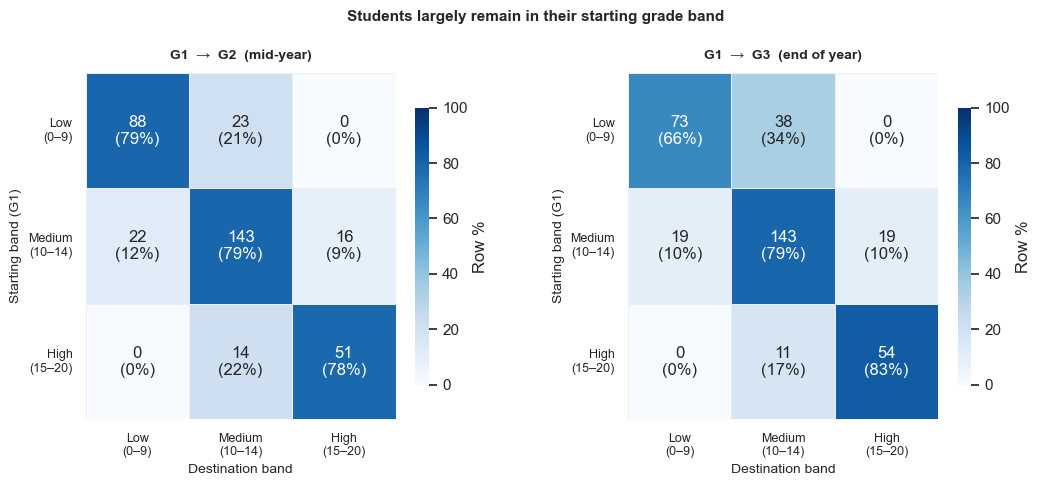


G1→G3 diagonal persistence rates:
  Low (0–9): 66% stay in same band
  Medium (10–14): 79% stay in same band
  High (15–20): 83% stay in same band


In [17]:
plot_df = mat_filtered.copy()

bins = [0, 9, 14, 20]
labels = ["Low\n(0–9)", "Medium\n(10–14)", "High\n(15–20)"]

plot_df["G1_band"] = pd.cut(
    plot_df["G1"], bins=bins, labels=labels, include_lowest=True
)
plot_df["G2_band"] = pd.cut(
    plot_df["G2"], bins=bins, labels=labels, include_lowest=True
)
plot_df["G3_band"] = pd.cut(
    plot_df["G3"], bins=bins, labels=labels, include_lowest=True
)


def make_transition(df, col_from, col_to):
    """Row-normalised transition matrix: rows = origin band, cols = destination band."""
    counts = pd.crosstab(df[col_from], df[col_to])
    counts = counts.reindex(index=labels, columns=labels, fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    return counts, pct


counts_12, pct_12 = make_transition(plot_df, "G1_band", "G2_band")
counts_13, pct_13 = make_transition(plot_df, "G1_band", "G3_band")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"wspace": 0.4})

for ax, counts, pct, title in zip(
    axes,
    [counts_12, counts_13],
    [pct_12, pct_13],
    ["G1  →  G2  (mid-year)", "G1  →  G3  (end of year)"],
):
    # Build annotation: "n\nxx%"
    annot = counts.astype(str) + "\n(" + pct.round(0).astype(int).astype(str) + "%)"

    sns.heatmap(
        pct,
        ax=ax,
        annot=annot,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="#eeeeee",
        cbar_kws={"label": "Row %", "shrink": 0.8},
    )
    ax.set_xlabel("Destination band", fontsize=10)
    ax.set_ylabel("Starting band (G1)", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=10)
    ax.tick_params(axis="x", labelsize=9, rotation=0)
    ax.tick_params(axis="y", labelsize=9, rotation=0)

fig.suptitle(
    "Students largely remain in their starting grade band",
    fontsize=11,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
fig_path = Path(".") / "figures" / "grade_band_transitions.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

# Print diagonal persistence rates
for label, counts, period in [(labels, pct_13, "G1→G3")]:
    diag = np.diag(counts.values)
    print(f"\n{period} diagonal persistence rates:")
    for band, rate in zip(labels, diag):
        print(f"  {band.replace(chr(10), ' ')}: {rate:.0f}% stay in same band")

### Do the better get better?

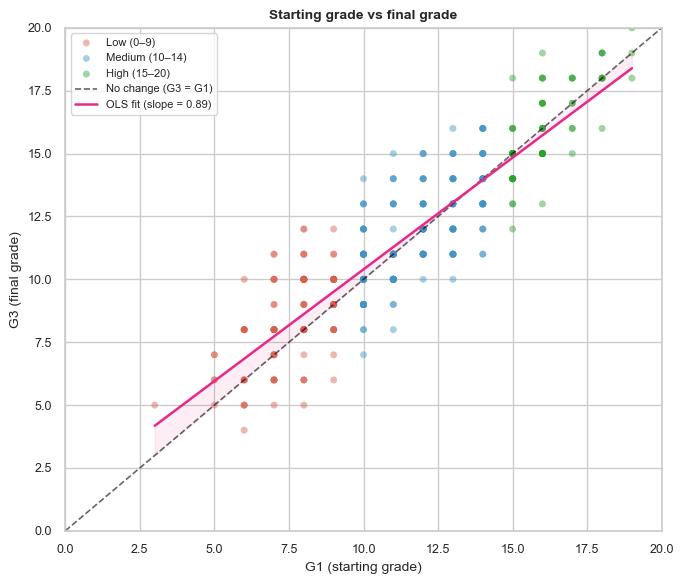

OLS: G3 = 1.51 + 0.89 × G1
Slope < 1 implies mean reversion: high starters decline, low starters improve on average


In [18]:
import numpy as np

plot_df = mat_filtered.copy()

band_colors = {
    "Low\n(0–9)": "#d6604d",
    "Medium\n(10–14)": "#4393c3",
    "High\n(15–20)": "#2ca02c",
}
bins = [0, 9, 14, 20]
labels = ["Low\n(0–9)", "Medium\n(10–14)", "High\n(15–20)"]
plot_df["G1_band"] = pd.cut(
    plot_df["G1"], bins=bins, labels=labels, include_lowest=True
)

fig, ax = plt.subplots(figsize=(7, 6))

# Plot each band
for band, color in band_colors.items():
    subset = plot_df[plot_df["G1_band"] == band]
    ax.scatter(
        subset["G1"],
        subset["G3"],
        color=color,
        alpha=0.45,
        s=25,
        label=band.replace("\n", " "),
        edgecolors="none",
    )

# y = x reference line (no change)
lims = [0, 20]
ax.plot(
    lims, lims, color="black", lw=1.2, ls="--", alpha=0.6, label="No change (G3 = G1)"
)

# OLS regression line
m, b = np.polyfit(plot_df["G1"], plot_df["G3"], 1)
x_line = np.linspace(plot_df["G1"].min(), plot_df["G1"].max(), 100)
ax.plot(
    x_line,
    m * x_line + b,
    color="#e7298a",
    lw=1.8,
    ls="-",
    label=f"OLS fit (slope = {m:.2f})",
)

# Shade the gap between y=x and OLS fit
ax.fill_between(x_line, x_line, m * x_line + b, alpha=0.08, color="#e7298a")

ax.set_xlim(0, 20)
ax.set_ylim(0, 20)
ax.set_xlabel("G1 (starting grade)", fontsize=10)
ax.set_ylabel("G3 (final grade)", fontsize=10)
ax.set_title("Starting grade vs final grade", fontsize=10, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.tick_params(labelsize=9)

plt.tight_layout()
fig_path = Path(".") / "figures" / "g1_vs_g3_scatter.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"OLS: G3 = {b:.2f} + {m:.2f} × G1")
print(
    "Slope < 1 implies mean reversion: high starters decline, low starters improve on average"
)

### Raw Correlation and Partialled Out Correlation

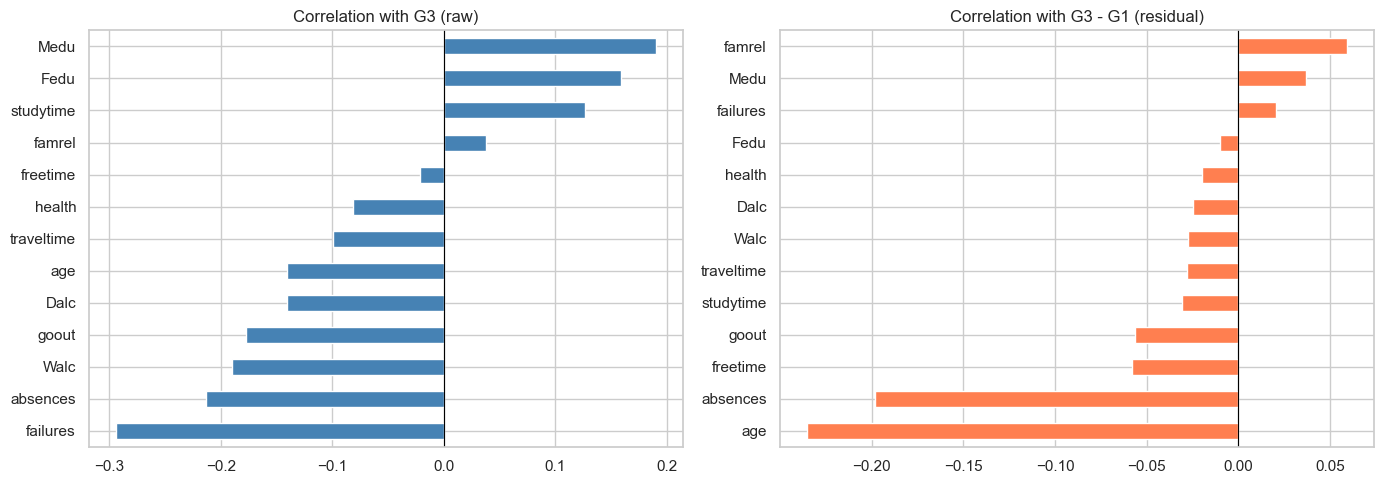

In [19]:
features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
]

corr_g3 = mat_filtered[features + ["G3"]].corr()["G3"].drop("G3")

plot_df = mat_filtered.copy()
plot_df["residual"] = plot_df["G3"] - plot_df["G1"]
corr_resid = (
    plot_df[features + ["residual"]].corr()["residual"].drop("residual")
)  # fix here

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
corr_g3.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Correlation with G3 (raw)")
axes[0].axvline(0, color="black", linewidth=0.8)

corr_resid.sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Correlation with G3 - G1 (residual)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

### Ranking absolute Correlation and tracking Changes

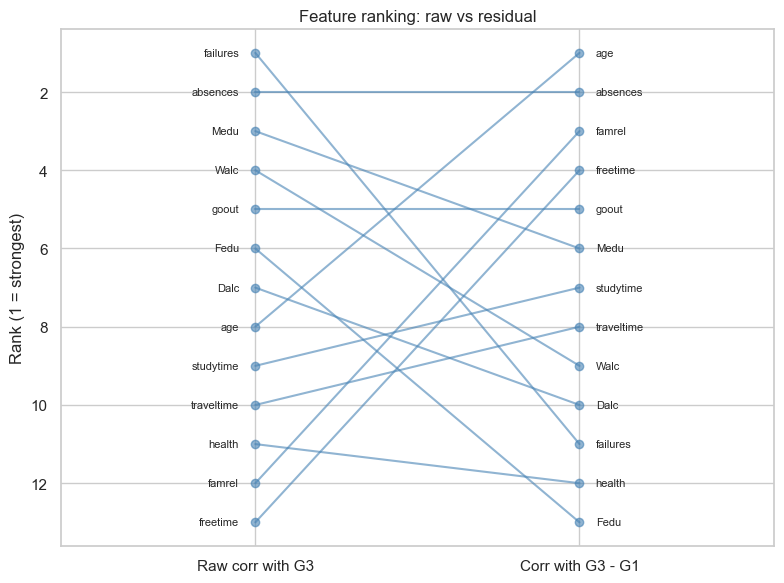

In [20]:
# Rank features by absolute correlation (1 = highest)
rank_g3 = corr_g3.abs().rank(ascending=False)
rank_resid = corr_resid.abs().rank(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))

for feature in features:
    ax.plot(
        [0, 1],
        [rank_g3[feature], rank_resid[feature]],
        "o-",
        color="steelblue",
        alpha=0.6,
    )
    ax.text(-0.05, rank_g3[feature], feature, ha="right", va="center", fontsize=8)
    ax.text(1.05, rank_resid[feature], feature, ha="left", va="center", fontsize=8)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Raw corr with G3", "Corr with G3 - G1"])
ax.set_ylabel("Rank (1 = strongest)")
ax.invert_yaxis()
ax.set_title("Feature ranking: raw vs residual")
ax.set_xlim(-0.6, 1.6)

plt.tight_layout()
plt.show()

## 4. Modelling

### Does background predict starting point?

Can student background (demographics, family, habits) predict where a student starts — their period-1 grade (G1)?

In [21]:
y_g1 = mat_filtered["G1"]
X, _, _ = prepare_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g1, test_size=0.2, random_state=42
)

# Scale AFTER splitting, fit on train only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

model = fit_lasso(X_train_scaled, y_train)

print(f"Best alpha: {model.best_params_['alpha']:.4f}")

results_g1 = evaluate_model(model, X_test_scaled, y_test)

print(f"\nTest MSE:  {results_g1['mse']:.4f}")
print(f"Test R²:   {results_g1['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(results_g1['nonzero_coefs'])}):")
for feature, coef in sorted(
    results_g1["nonzero_coefs"].items(), key=lambda x: abs(x[1]), reverse=True
):
    print(f"  {feature:15s}  {coef:+.4f}")

Best alpha: 0.0429

Test MSE:  8.0309
Test R²:   0.1505

Non-zero coefficients (13):
  failures         -0.7621
  goout            -0.3249
  Fedu             +0.2697
  studytime        +0.2694
  freetime         +0.2690
  age              +0.2352
  health           -0.2249
  absences         -0.2159
  Medu             +0.1544
  Walc             -0.1048
  Dalc             -0.0647
  traveltime       +0.0223
  famrel           +0.0193


### Lasso model — predicting grade change (G3 − G1) without categoricals

In [22]:
X, y_g3_g1, y_g2_g1 = prepare_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g3_g1, test_size=0.2, random_state=42
)

# Scale AFTER splitting, fit on train only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
model = fit_lasso(X_train_scaled, y_train)

print(f"Best alpha: {model.best_params_['alpha']:.4f}")

results_lasso_numeric = evaluate_model(model, X_test_scaled, y_test)

print(f"\nTest MSE:  {results_lasso_numeric['mse']:.4f}")
print(f"Test R²:   {results_lasso_numeric['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(results_lasso_numeric['nonzero_coefs'])}):")
for feature, coef in sorted(
    results_lasso_numeric["nonzero_coefs"].items(),
    key=lambda x: abs(x[1]),
    reverse=True,
):
    print(f"  {feature:15s}  {coef:+.4f}")

Best alpha: 0.1326

Test MSE:  2.0505
Test R²:   0.0573

Non-zero coefficients (3):
  age              -0.1897
  absences         -0.1294
  freetime         -0.0131


### Lasso model - predicting grade change (G3 - G1) with categoricals

In [23]:
X, y_g3_g1, y_g2_g1 = encode_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g3_g1, test_size=0.2, random_state=42
)

# One-hot encode using train categories only, then align test columns
X_train_enc, X_test_enc = apply_dummies(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc), columns=X_train_enc.columns
)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns)

model = fit_lasso(X_train_scaled, y_train)

print(f"Best alpha: {model.best_params_['alpha']:.4f}")

results_lasso_encoded = evaluate_model(model, X_test_scaled, y_test)

print(f"\nTest MSE:  {results_lasso_encoded['mse']:.4f}")
print(f"Test R²:   {results_lasso_encoded['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(results_lasso_encoded['nonzero_coefs'])}):")
for feature, coef in sorted(
    results_lasso_encoded["nonzero_coefs"].items(),
    key=lambda x: abs(x[1]),
    reverse=True,
):
    print(f"  {feature:15s}  {coef:+.4f}")

Best alpha: 0.1600

Test MSE:  2.0668
Test R²:   0.0498

Non-zero coefficients (4):
  age              -0.1546
  absences         -0.1113
  school_MS        -0.0277
  internet_yes     +0.0062


### Ridge model — predicting grade change (G3 − G1) without categoricals

In [24]:
X, y_g3_g1, y_g2_g1 = prepare_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g3_g1, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

model = fit_ridge(X_train_scaled, y_train)

print(f"Best alpha: {model.best_params_['alpha']:.4f}")

results_ridge_numeric = evaluate_model(model, X_test_scaled, y_test)

print(f"\nTest MSE:  {results_ridge_numeric['mse']:.4f}")
print(f"Test R²:   {results_ridge_numeric['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(results_ridge_numeric['nonzero_coefs'])}):")
for feature, coef in sorted(
    results_ridge_numeric["nonzero_coefs"].items(),
    key=lambda x: abs(x[1]),
    reverse=True,
):
    print(f"  {feature:15s}  {coef:+.4f}")

Best alpha: 10.0000

Test MSE:  2.2264
Test R²:   -0.0236

Non-zero coefficients (13):
  age              -0.3304
  absences         -0.2822
  freetime         -0.2096
  Fedu             -0.1891
  Medu             +0.1731
  famrel           +0.1637
  failures         +0.1572
  traveltime       -0.1227
  studytime        -0.1003
  goout            -0.0671
  Dalc             +0.0433
  Walc             +0.0325
  health           -0.0132


### Ridge model — predicting grade change (G3 − G1) with categoricals

In [25]:
# mat_filtered already defined earlier in notebook — do not redefine here

X, y_g3_g1, y_g2_g1 = encode_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g3_g1, test_size=0.2, random_state=42
)

# One-hot encode using train categories only, then align test columns
X_train_enc, X_test_enc = apply_dummies(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc), columns=X_train_enc.columns
)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns)

model = fit_ridge(X_train_scaled, y_train)

print(f"Best alpha: {model.best_params_['alpha']:.4f}")

results_ridge_encoded = evaluate_model(model, X_test_scaled, y_test)

print(f"\nTest MSE:  {results_ridge_encoded['mse']:.4f}")
print(f"Test R²:   {results_ridge_encoded['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(results_ridge_encoded['nonzero_coefs'])}):")
for feature, coef in sorted(
    results_ridge_encoded["nonzero_coefs"].items(),
    key=lambda x: abs(x[1]),
    reverse=True,
):
    print(f"  {feature:15s}  {coef:+.4f}")

Best alpha: 10.0000

Test MSE:  3.0028
Test R²:   -0.3805

Non-zero coefficients (39):
  absences         -0.4172
  sex_M            -0.2762
  internet_yes     +0.2547
  Pstatus_T        -0.2124
  failures         +0.1876
  Mjob_other       +0.1806
  famrel           +0.1794
  Fjob_other       +0.1735
  guardian_other   -0.1667
  age              -0.1604
  freetime         -0.1595
  higher_yes       -0.1562
  famsup_yes       +0.1527
  studytime        -0.1438
  school_MS        -0.1402
  goout            -0.1361
  Mjob_services    +0.1308
  Fedu             -0.1203
  Mjob_health      +0.1138
  traveltime       -0.1133
  Medu             +0.1103
  Fjob_services    +0.1065
  Mjob_teacher     +0.0986
  reason_home      +0.0951
  reason_reputation  -0.0895
  reason_other     +0.0892
  nursery_yes      -0.0753
  Walc             +0.0687
  romantic_yes     -0.0610
  famsize_LE3      -0.0583
  Dalc             +0.0438
  paid_yes         -0.0428
  schoolsup_yes    +0.0409
  Fjob_health      -

### Elastic Net - predicting grade change (G3 - G1) without categoricals 

In [26]:
# Explicit data prep — don't rely on whatever X_train_scaled is in scope
X, y_g3_g1, _ = prepare_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g3_g1, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

enet_gs = fit_elastic_net(X_train_scaled, y_train)
enet_results = evaluate_model(enet_gs, X_test_scaled, y_test)

best_alpha = enet_gs.best_params_["alpha"]
best_l1_ratio = enet_gs.best_params_["l1_ratio"]

print(f"Best alpha:    {best_alpha:.4f}")
print(f"Best l1_ratio: {best_l1_ratio:.4f}  (1.0 = pure Lasso, 0.0 = pure Ridge)")
print(f"Test MSE:      {enet_results['mse']:.4f}")
print(f"Test R²:       {enet_results['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(enet_results['nonzero_coefs'])}):")
for feat, coef in sorted(
    enet_results["nonzero_coefs"].items(), key=lambda x: abs(x[1]), reverse=True
):
    print(f"  {feat:<20} {coef:+.4f}")

Best alpha:    0.1610
Best l1_ratio: 0.9000  (1.0 = pure Lasso, 0.0 = pure Ridge)
Test MSE:      2.0546
Test R²:       0.0554

Non-zero coefficients (3):
  age                  -0.1774
  absences             -0.1164
  freetime             -0.0001


### Elastic Net - predicting grade change (G3 - G1) with categoricals 

In [27]:
from src.models import fit_elastic_net

X, y_g3_g1, _ = encode_features(mat_filtered)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_g3_g1, test_size=0.2, random_state=42
)

# One-hot encode using train categories only, then align test columns
X_train_enc, X_test_enc = apply_dummies(X_train, X_test)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_enc), columns=X_train_enc.columns
)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns)

enet_gs_encoded = fit_elastic_net(X_train_scaled, y_train)
enet_results_encoded = evaluate_model(enet_gs_encoded, X_test_scaled, y_test)

best_alpha = enet_gs_encoded.best_params_["alpha"]
best_l1_ratio = enet_gs_encoded.best_params_["l1_ratio"]

print(f"Best alpha:    {best_alpha:.4f}")
print(f"Best l1_ratio: {best_l1_ratio:.4f}  (1.0 = pure Lasso, 0.0 = pure Ridge)")
print(f"Test MSE:      {enet_results_encoded['mse']:.4f}")
print(f"Test R²:       {enet_results_encoded['r2']:.4f}")
print(f"\nNon-zero coefficients ({len(enet_results_encoded['nonzero_coefs'])}):")
for feat, coef in sorted(
    enet_results_encoded["nonzero_coefs"].items(), key=lambda x: abs(x[1]), reverse=True
):
    print(f"  {feat:<20} {coef:+.4f}")

Best alpha:    0.3039
Best l1_ratio: 0.5000  (1.0 = pure Lasso, 0.0 = pure Ridge)
Test MSE:      2.0798
Test R²:       0.0439

Non-zero coefficients (5):
  age                  -0.1354
  absences             -0.1071
  school_MS            -0.0356
  internet_yes         +0.0128
  guardian_other       -0.0081


### Model comparison summary

In [28]:
summary = (
    pd.DataFrame(
        [
            {
                "Model": "Lasso",
                "Features": "Numeric only",
                "MSE": results_lasso_numeric["mse"],
                "R²": results_lasso_numeric["r2"],
            },
            {
                "Model": "Lasso",
                "Features": "One-hot encoded",
                "MSE": results_lasso_encoded["mse"],
                "R²": results_lasso_encoded["r2"],
            },
            {
                "Model": "Ridge",
                "Features": "Numeric only",
                "MSE": results_ridge_numeric["mse"],
                "R²": results_ridge_numeric["r2"],
            },
            {
                "Model": "Ridge",
                "Features": "One-hot encoded",
                "MSE": results_ridge_encoded["mse"],
                "R²": results_ridge_encoded["r2"],
            },
            {
                "Model": "Elastic Net",
                "Features": "Numeric only",
                "MSE": enet_results["mse"],
                "R²": enet_results["r2"],
            },
            {
                "Model": "Elastic Net",
                "Features": "One-hot encoded",
                "MSE": enet_results_encoded["mse"],
                "R²": enet_results_encoded["r2"],
            },
        ]
    )
    .set_index(["Model", "Features"])
    .round(4)
)

summary

MSE      R²
Model       Features                       
Lasso       Numeric only     2.0505  0.0573
            One-hot encoded  2.0668  0.0498
Ridge       Numeric only     2.2264 -0.0236
            One-hot encoded  3.0028 -0.3805
Elastic Net Numeric only     2.0546  0.0554
            One-hot encoded  2.0798  0.0439

## 05. Robustness Checks

Replicating all models on the Portuguese dataset to assess whether the Math findings generalise.

In [29]:
model_specs = [
    ("Lasso", fit_lasso, "Numeric only", prepare_features),
    ("Lasso", fit_lasso, "One-hot encoded", encode_features),
    ("Ridge", fit_ridge, "Numeric only", prepare_features),
    ("Ridge", fit_ridge, "One-hot encoded", encode_features),
    ("Elastic Net", fit_elastic_net, "Numeric only", prepare_features),
    ("Elastic Net", fit_elastic_net, "One-hot encoded", encode_features),
]

rows = []

for model_name, fit_fn, feature_label, feature_fn in model_specs:
    # Prepare features
    X, y_g3_g1, _ = feature_fn(por_filtered)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_g3_g1, test_size=0.2, random_state=42
    )

    # One-hot encode on train only when using categorical features
    if feature_fn is encode_features:
        X_train, X_test = apply_dummies(X_train, X_test)

    # Scale — fit on train only
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns
    )
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    # Fit and evaluate
    fitted = fit_fn(X_train_scaled, y_train)
    results = evaluate_model(fitted, X_test_scaled, y_test)

    rows.append(
        {
            "Model": model_name,
            "Features": feature_label,
            "MSE": results["mse"],
            "R²": results["r2"],
        }
    )
    print(f"Done: {model_name} ({feature_label})")

summary_por = pd.DataFrame(rows).set_index(["Model", "Features"]).round(4)

summary_por

Done: Lasso (Numeric only)
Done: Lasso (One-hot encoded)
Done: Ridge (Numeric only)
Done: Ridge (One-hot encoded)
Done: Elastic Net (Numeric only)
Done: Elastic Net (One-hot encoded)


MSE      R²
Model       Features                       
Lasso       Numeric only     1.9867  0.0418
            One-hot encoded  2.0292  0.0213
Ridge       Numeric only     1.9181  0.0748
            One-hot encoded  2.0783 -0.0024
Elastic Net Numeric only     1.9828  0.0436
            One-hot encoded  2.0285  0.0216

## 6. Regularisation Path Visualisation

How do Lasso and Ridge coefficients change as regularisation strength varies?  
The vertical dashed line marks the optimal α selected by 5-fold CV.

### Regularisation Path — G1 Baseline vs Trajectory

Do the same features predict *where a student starts* (G1) versus *how they change* (G3 − G1)?  
The Lasso path for each outcome is shown side by side, with a shared colour per feature for direct comparison.

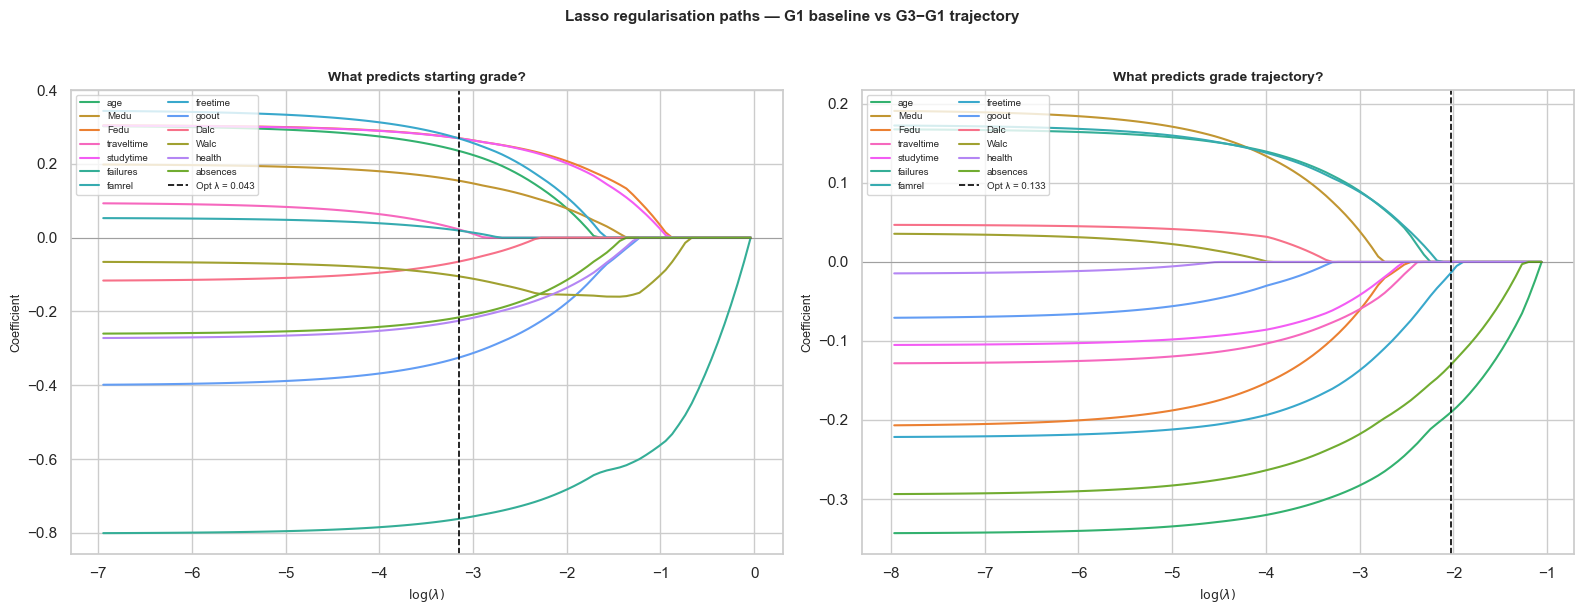

In [31]:
from sklearn.linear_model import lasso_path

# --- Outcome 1: G1 baseline ---
X_mat, _, _ = prepare_features(mat_filtered)
y_g1 = mat_filtered["G1"]

X_g1_train, X_g1_test, yg1_train, yg1_test = train_test_split(
    X_mat, y_g1, test_size=0.2, random_state=42
)
scaler_g1 = StandardScaler()
X_g1_train_s = scaler_g1.fit_transform(X_g1_train)

# --- Outcome 2: G3-G1 trajectory ---
X_traj, y_g3g1_mat, _ = prepare_features(mat_filtered)

X_traj_train, X_traj_test, ytraj_train, ytraj_test = train_test_split(
    X_traj, y_g3g1_mat, test_size=0.2, random_state=42
)
scaler_traj = StandardScaler()
X_traj_train_s = scaler_traj.fit_transform(X_traj_train)

# --- Optimal alphas via CV ---
lasso_g1_gs = fit_lasso(X_g1_train_s, yg1_train)
lasso_traj_gs = fit_lasso(X_traj_train_s, ytraj_train)

opt_alpha_g1 = lasso_g1_gs.best_params_["alpha"]
opt_alpha_traj = lasso_traj_gs.best_params_["alpha"]

# --- Lasso regularisation paths ---
alphas_g1, coefs_g1, _ = lasso_path(X_g1_train_s, yg1_train, n_alphas=100)
alphas_traj, coefs_traj, _ = lasso_path(X_traj_train_s, ytraj_train, n_alphas=100)

feature_names = X_mat.columns.tolist()

# Shared colour palette so same feature = same colour across both panels
all_features = sorted(set(feature_names))
palette_map = dict(zip(all_features, sns.color_palette("husl", len(all_features))))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

panel_specs = [
    (axes[0], "What predicts starting grade?", alphas_g1, coefs_g1, opt_alpha_g1),
    (
        axes[1],
        "What predicts grade trajectory?",
        alphas_traj,
        coefs_traj,
        opt_alpha_traj,
    ),
]

for ax, title, alphas, coefs, opt_alpha in panel_specs:
    log_a = np.log(alphas)
    for name, coef_row in zip(feature_names, coefs):
        ax.plot(log_a, coef_row, color=palette_map[name], label=name, linewidth=1.5)
    ax.axvline(
        np.log(opt_alpha),
        color="black",
        ls="--",
        lw=1.2,
        label=f"Opt λ = {opt_alpha:.3f}",
    )
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(r"$\log(\lambda)$", fontsize=9)
    ax.set_ylabel("Coefficient", fontsize=9)
    ax.axhline(0, color="black", lw=0.5, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left", ncol=2)

fig.suptitle(
    "Lasso regularisation paths — G1 baseline vs G3−G1 trajectory",
    fontsize=11,
    fontweight="bold",
    y=1.02,
)
fig.tight_layout()

fig_path = Path(".") / "figures" / "lasso_paths_scaled.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

## 7. Classification: predicting improve/decline
Reframe problem as binary classification problem: can demographic and lifestyle features predict whether a student's grade trajectory is positive or flat (G3 − G1 ≥ 0) versus declining?

In [30]:
# Binary target
mat_filtered = mat_filtered.drop(columns=["trajectory"], errors="ignore")
X, _, _ = prepare_features(mat_filtered)
y_pass = (mat_filtered["G3"] - mat_filtered["G1"] >= 0).astype(int)

print(
    f"Class balance — Decline: {(y_pass == 0).sum()}  Improve: {(y_pass == 1).sum()}"
    f"  ({y_pass.mean() * 100:.1f}% improve rate)"
)

Class balance — Decline: 121  Improve: 236  (66.1% improve rate)


In [31]:
# Train/test split and rescaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y_pass, test_size=0.2, random_state=42, stratify=y_pass
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
# Logit regression with L1 penalty (Lasso)
logit_gs = fit_logistic(X_train_scaled, y_train)
logit_res = evaluate_classifier(logit_gs, X_test_scaled, y_test)

print("Logistic Regression (L1)")
print(f"Best C (inverse regularisation): {logit_gs.best_params_['C']:.4f}")
print(f"Accuracy:      {logit_res['accuracy']:.4f}")
print(f"Cross entropy: {logit_res['cross_entropy']:.4f}")
print(f"ROC-AUC:       {logit_res['roc_auc']:.4f}")
print(f"\n{logit_res['report']}")


── Logistic Regression (L1) ──────────────────────────
Best C (inverse regularisation): 0.0869
Accuracy:      0.7222
Cross entropy: 0.6744
ROC-AUC:       0.6089

              precision    recall  f1-score   support

        Fail       0.60      0.50      0.55        24
        Pass       0.77      0.83      0.80        48

    accuracy                           0.72        72
   macro avg       0.68      0.67      0.67        72
weighted avg       0.71      0.72      0.72        72



In [41]:
# Random Forest classifier
rf_gs = fit_random_forest(X_train_scaled, y_train)
rf_res = evaluate_classifier(rf_gs, X_test_scaled, y_test)

print("Random Forest")
print(f"Best params: {rf_gs.best_params_}")
print(f"Accuracy:      {rf_res['accuracy']:.4f}")
print(f"Cross entropy: {rf_res['cross_entropy']:.4f}")
print(f"ROC-AUC:       {rf_res['roc_auc']:.4f}")
print(f"\n{rf_res['report']}")

Random Forest
Best params: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100}
Accuracy:      0.6667
Cross entropy: 0.6057
ROC-AUC:       0.6823

              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        24
        Pass       0.67      1.00      0.80        48

    accuracy                           0.67        72
   macro avg       0.33      0.50      0.40        72
weighted avg       0.44      0.67      0.53        72



In [34]:
# Summary Table
summary_clf = (
    pd.DataFrame(
        [
            {
                "Model": "Logistic Regression (L1)",
                "Accuracy": logit_res["accuracy"],
                "Cross Entropy": logit_res["cross_entropy"],
                "ROC-AUC": logit_res["roc_auc"],
            },
            {
                "Model": "Random Forest",
                "Accuracy": rf_res["accuracy"],
                "Cross Entropy": rf_res["cross_entropy"],
                "ROC-AUC": rf_res["roc_auc"],
            },
        ]
    )
    .set_index("Model")
    .round(4)
)

summary_clf

,Accuracy,Cross Entropy,ROC-AUC
Model,,,
Logistic Regression (L1),0.7222,0.6744,0.6089
Random Forest,0.6667,0.6057,0.6823


In [35]:
# Dummy classifier baseline (most frequent class)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test_scaled))

print(f"Dummy classifier (always predict majority class): {dummy_acc:.4f}")
print(
    f"Logistic Regression accuracy gain over dummy:     {logit_res['accuracy'] - dummy_acc:+.4f}"
)
print(
    f"Random Forest accuracy gain over dummy:           {rf_res['accuracy'] - dummy_acc:+.4f}"
)

Dummy classifier (always predict majority class): 0.6667
Logistic Regression accuracy gain over dummy:     +0.0556
Random Forest accuracy gain over dummy:           +0.0000


In [36]:
# Logit regression non-zero coefficients
best_logit = logit_gs.best_estimator_
coef_series = pd.Series(best_logit.coef_[0], index=X_test_scaled.columns)
nonzero = coef_series[coef_series.abs() > 1e-6].sort_values()

print(f"Best C: {logit_gs.best_params_['C']:.4f}")
print(f"Non-zero coefficients ({len(nonzero)} of {len(coef_series)}):\n")
for feat, coef in nonzero.items():
    print(f"  {feat:<20} {coef:+.4f}")

Best C: 0.0869
Non-zero coefficients (1 of 13):

  absences             -0.1202


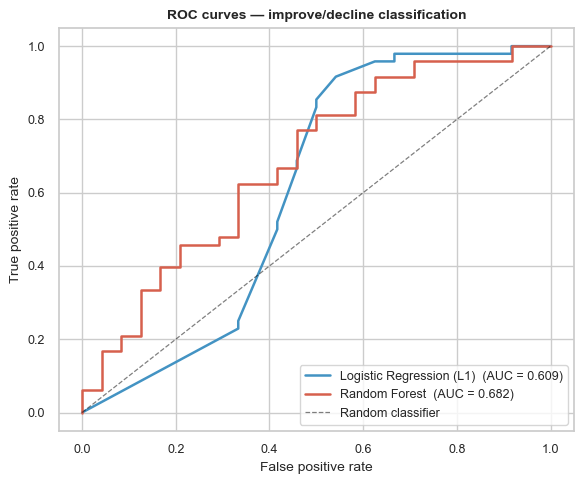

In [37]:
fig, ax = plt.subplots(figsize=(6, 5))

for label, gs, color in [
    ("Logistic Regression (L1)", logit_gs, "#4393c3"),
    ("Random Forest", rf_gs, "#d6604d"),
]:
    best = gs.best_estimator_
    y_prob = best.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{label}  (AUC = {auc:.3f})")

ax.plot(
    [0, 1], [0, 1], color="black", lw=0.9, ls="--", alpha=0.5, label="Random classifier"
)
ax.set_xlabel("False positive rate", fontsize=10)
ax.set_ylabel("True positive rate", fontsize=10)
ax.set_title(
    "ROC curves — improve/decline classification", fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9)
ax.tick_params(labelsize=9)

plt.tight_layout()
fig_path = Path(".") / "figures" / "roc_curves.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

## 8. SHAP Evaluation

In [38]:
# SHAP values for Random Forest
best_rf = rf_gs.best_estimator_

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_scaled)

# Older SHAP returns a list [class_0, class_1]; newer SHAP returns a 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_pass = shap_values[1]
elif shap_values.ndim == 3:
    shap_pass = shap_values[:, :, 1]
else:
    shap_pass = shap_values

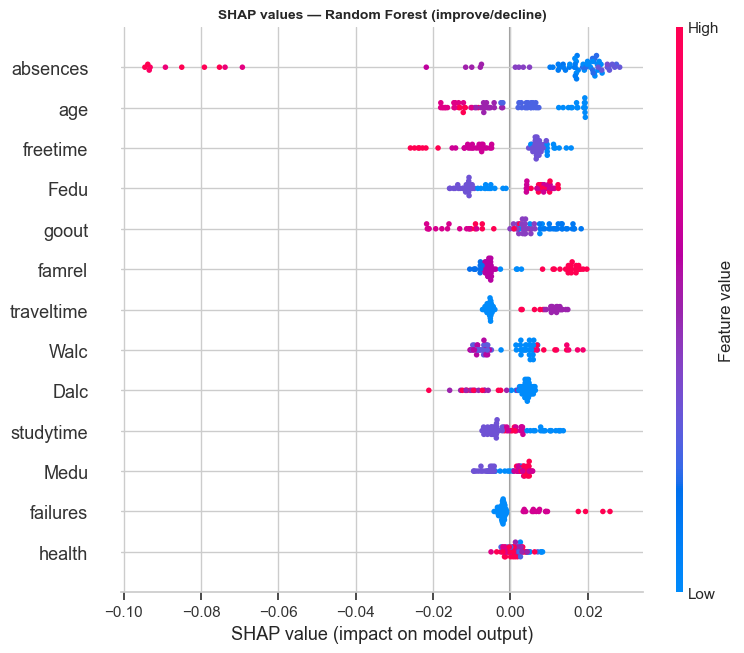

In [39]:
# Beeswarm plot of SHAP values

shap.summary_plot(shap_pass, X_test_scaled, plot_type="dot", show=False)
plt.title(
    "SHAP values — Random Forest (improve/decline)", fontsize=10, fontweight="bold"
)
plt.tight_layout()
fig_path = Path(".") / "figures" / "shap_summary.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

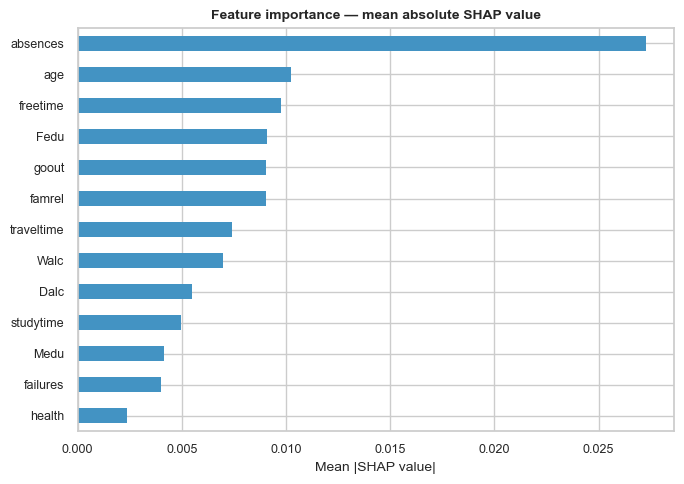

Top features by mean |SHAP|:
absences    0.0273
age         0.0103
freetime    0.0097
Fedu        0.0091
goout       0.0090
dtype: float64


In [40]:
# Bar plot of mean absolute SHAP values for feature importance

mean_shap = pd.Series(
    np.abs(shap_pass).mean(axis=0), index=X_test_scaled.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
mean_shap.plot.barh(ax=ax, color="#4393c3", edgecolor="none")
ax.set_xlabel("Mean |SHAP value|", fontsize=10)
ax.set_title(
    "Feature importance — mean absolute SHAP value", fontsize=10, fontweight="bold"
)
ax.tick_params(labelsize=9)
plt.tight_layout()
fig_path = Path(".") / "figures" / "shap_importance.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

# Print top 5 features by mean absolute SHAP
print("Top features by mean |SHAP|:")
print(mean_shap.sort_values(ascending=False).head(5).round(4))